# **Assignment 3: Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the effect of different learning rates and the number of epochs on model performance**

In [3]:
# 1. Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [4]:
# 2. Load the wine dataset
wine = load_wine()

X = wine.data
y = wine.target

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Class names:", wine.target_names)

Input shape: (178, 13)
Target shape: (178,)
Class names: ['class_0' 'class_1' 'class_2']


In [5]:
# 3. Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (142, 13)
Testing samples: (36, 13)


In [6]:
# 4. Standardize the data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("First training sample:")
print(X_train[0])

First training sample:
[ 0.38580089 -0.63787118  1.77666817 -1.22453161  0.69643032  0.52686525
  0.73229212 -0.1695489  -0.41578344 -0.16746725  0.62437819  0.2529082
  0.46772474]


In [7]:
# 5. Create the MLP Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(13,)),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(3, activation='softmax')
])

In [8]:
# 6. Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# 7. Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 405ms/step - accuracy: 0.8142 - loss: 0.8418 - val_accuracy: 0.8966 - val_loss: 0.7106
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9115 - loss: 0.7257 - val_accuracy: 0.9655 - val_loss: 0.6124
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9646 - loss: 0.6229 - val_accuracy: 0.9655 - val_loss: 0.5268
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9735 - loss: 0.5341 - val_accuracy: 1.0000 - val_loss: 0.4503
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9912 - loss: 0.4567 - val_accuracy: 1.0000 - val_loss: 0.3827
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9912 - loss: 0.3894 - val_accuracy: 1.0000 - val_loss: 0.3228
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9912 - loss: 0.3307 - val_accuracy: 1.0000 - val_loss: 0.2706
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9912 - loss: 0.2804 - val_accuracy: 1.0000 - val_loss: 0.2270

### 8. Understand the forward and Backward Propagation
This happens automatically inside model.fit().

**Forward propagation**

The input goes through the network:

*Wine features*
      
      ↓

*Dense 64*
      
      ↓
*Dense 32*
      
      ↓
*Softmax*
      
      ↓
*Prediction*

The model calculates its prediction.

Loss calculation

The prediction is compared with the actual class.

*Prediction + Actual value*
          
         ↓        
*Loss*

**Backpropagation**

TensorFlow calculates how much each weight contributed to the error and adjusts the weights.

*Loss*

    ↓

*Calculate gradients*

    ↓

*Update weights*

    ↓

*Better prediction*

This process repeats for every batch during training.

In [10]:
# 9. Evaluate the Model

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.1127474308013916
Test Accuracy: 0.9444444179534912


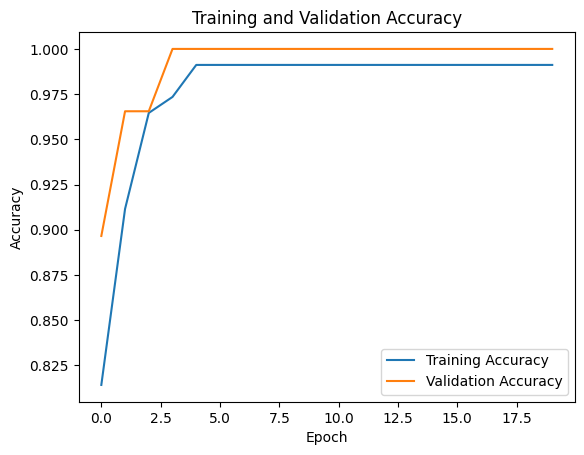

In [11]:
# 10. Plot Training Accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

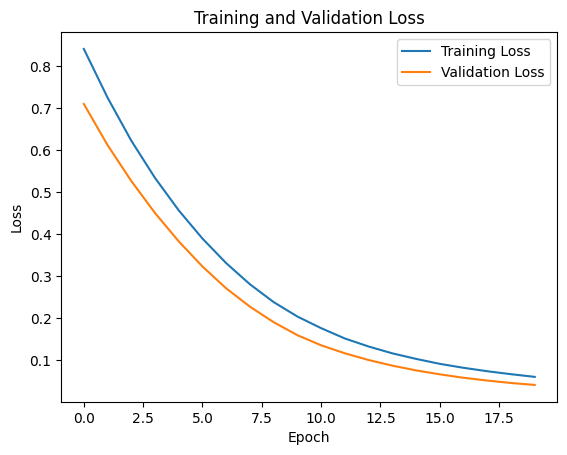

In [12]:
# 11. Plot Loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [14]:
# 13.Run the learning-rate experiment

def create_model(learning_rate):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(13,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

  learning_rates = [0.1, 0.01, 0.001, 0.0001]

lr_accuracies = []

for lr in learning_rates:

    print("Learning Rate:", lr)

    model = create_model(lr)

    model.fit(
        X_train,
        y_train,
        epochs=20,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    lr_accuracies.append(accuracy)

    print("Test Accuracy:", accuracy)
    print()

Learning Rate: 0.1
Test Accuracy: 0.9722222089767456

Learning Rate: 0.01
Test Accuracy: 1.0

Learning Rate: 0.001
Test Accuracy: 0.9722222089767456

Learning Rate: 0.0001
Test Accuracy: 0.7222222089767456



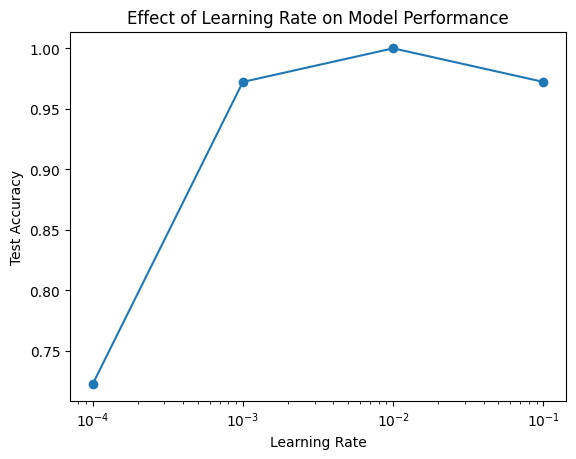

In [15]:
# 14. Plot learning rate vs accuracy

plt.plot(learning_rates, lr_accuracies, marker='o')

plt.xscale('log')

plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('Effect of Learning Rate on Model Performance')

plt.show()